# Steam Q4 — RAPIDS GPU genre analysis
**Question:** Among common game genres, which have higher shares meeting the 50K-owner threshold?

**Run in Google Colab:** Runtime → Change runtime type → select an available NVIDIA GPU (e.g. T4) → Save. Run cells in order. Upload the same `clean_output/steam_clean.csv` used in the original EDA. Includes zero-price games. No local Mac installation needed.

**GPU:** direct cuDF loading, splitting/exploding, filtering, deduplication, aggregation, success rates and Wilson interval calculations. **CPU:** Matplotlib rendering and a separate pandas correctness check. No speedup is claimed.

This file has no executed GPU outputs yet. Run it on Colab and save the executed notebook for your rubric evidence.

[NVIDIA Colab instructions](https://docs.nvidia.com/datascience/deployment/latest/platforms/colab/) • [cuDF groupby](https://docs.rapids.ai/api/cudf/legacy/user_guide/groupby/)

## 1. Verify GPU and import libraries
cuDF is normally preinstalled on Colab. If it is missing, use the optional installation instructions below. A GPU runtime is required.

In [1]:
import subprocess, hashlib, json, shutil
from pathlib import Path
import cudf
import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from google.colab import files

assert cp.cuda.runtime.getDeviceCount() > 0, "Select a GPU runtime first."
gpu_info = subprocess.check_output(
    ["nvidia-smi", "--query-gpu=name,driver_version", "--format=csv,noheader"], text=True
).strip()
print("GPU / driver:", gpu_info)
print("RAPIDS cuDF:", cudf.__version__)
print("GPU calculation check:", int(cudf.Series([1, 2, 3]).sum()))
OUT = Path("steam_gpu_q4_output")
OUT.mkdir(exist_ok=True)

GPU / driver: Tesla T4, 580.82.07
RAPIDS cuDF: 26.06.00
GPU calculation check: 6


**Optional, only if cuDF is missing:** run this official installer in a temporary code cell, restart the runtime, then rerun Step 1:
```python
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py
```
## 2. Upload steam_clean.csv
Choose only the cleaned CSV, not the raw Kaggle file or the model-training export.

In [2]:
uploaded = files.upload()
assert len(uploaded) == 1, "Upload only steam_clean.csv."
DATA_PATH = Path(next(iter(uploaded)))
del uploaded
gdf = cudf.read_csv(str(DATA_PATH), usecols=["AppID", "owners_low", "success_50k", "genres"])
assert len(gdf) > 0
assert gdf["AppID"].notna().all() and not gdf["AppID"].duplicated().any()
assert gdf["owners_low"].notna().all() and gdf["success_50k"].notna().all()
assert gdf["success_50k"].eq((gdf["owners_low"] >= 50_000).astype("int32")).all(), "Success definition mismatch."
gdf["success_50k"] = gdf["success_50k"].astype("int32")
baseline = float(gdf["success_50k"].mean()) * 100
print(f"Loaded {len(gdf):,} games; overall threshold rate: {baseline:.2f}%")
print("DataFrame type:", type(gdf))
print("Original export reference: 95,787 games; 14.63% overall.")

Saving steam_clean.csv to steam_clean.csv
Loaded 95,787 games; overall threshold rate: 14.63%
DataFrame type: <class 'cudf.core.dataframe.DataFrame'>
Original export reference: 95,787 games; 14.63% overall.


## 3. Process and aggregate on the GPU
Counts each game once per genre; genre groups overlap. Preserves original genre exclusions. Selects the ten largest eligible genres with at least 100 games, then orders by rate. Direct cuDF operations do not use pandas accelerator fallback.

In [3]:
excluded = [
    "free to play", "early access", "utilities", "design & illustration",
    "animation & modeling", "audio production", "video production", "photo editing",
    "web publishing", "education", "software training", "accounting",
    "game development", "movie", "documentary", "episodic", "short", "tutorial", "360 video"
]
long_gpu = gdf[["AppID", "success_50k"]].copy()
long_gpu["genre"] = gdf["genres"].fillna("").str.split(",", expand=False)
long_gpu = long_gpu.explode("genre")
long_gpu["genre"] = long_gpu["genre"].str.strip()
long_gpu = long_gpu.loc[
    long_gpu["genre"].notna() & long_gpu["genre"].ne("") &
    ~long_gpu["genre"].str.lower().isin(excluded)
].drop_duplicates(["AppID", "genre"])
summary_gpu = long_gpu.groupby("genre")["success_50k"].agg(["count", "sum"])
summary_gpu.columns = ["games", "hits"]
summary_gpu = summary_gpu.reset_index()
summary_gpu = summary_gpu.loc[summary_gpu["games"] >= 100]
summary_gpu = summary_gpu.sort_values(["games", "genre"], ascending=[False, True]).head(10)
assert len(summary_gpu) > 0, "No eligible genres."
p = summary_gpu["hits"] / summary_gpu["games"]
n = summary_gpu["games"]
z = 1.96
denominator = 1 + z*z/n
center = (p + z*z/(2*n)) / denominator
half = z * (p*(1-p)/n + z*z/(4*n*n))**0.5 / denominator
summary_gpu["rate_pct"] = 100*p
summary_gpu["lower_pct"] = 100*(center-half)
summary_gpu["upper_pct"] = 100*(center+half)
summary_gpu = summary_gpu.sort_values(["rate_pct", "genre"], ascending=[False, True])
cp.cuda.Stream.null.synchronize()
print("GPU result type:", type(summary_gpu))
print("GPU genre aggregation and interval calculations completed.")
# Transfer only the final table to CPU for plotting.
t4 = summary_gpu.to_pandas().set_index("genre")
display(t4.round(2))
t4.to_csv(OUT / "04_genre_rates_gpu.csv")

GPU result type: <class 'cudf.core.dataframe.DataFrame'>
GPU genre aggregation and interval calculations completed.


,games,hits,rate_pct,lower_pct,upper_pct
genre,,,,,
Massively Multiplayer,1862,604,32.44,30.35,34.60
RPG,17712,3530,19.93,19.35,20.52
Strategy,18965,3494,18.42,17.88,18.98
Action,39747,6507,16.37,16.01,16.74
Adventure,38655,5951,15.40,15.04,15.76
Simulation,20159,3077,15.26,14.77,15.77
Racing,3457,485,14.03,12.91,15.23
Indie,68697,8935,13.01,12.76,13.26
Sports,4160,513,12.33,11.37,13.37


## 4. Validate counts and rates against pandas
This CPU check verifies the GPU result for the uploaded file. It is not a timing benchmark.

In [4]:
cpu = pd.read_csv(DATA_PATH, usecols=["AppID", "success_50k", "genres"])
cpu["genre"] = cpu["genres"].fillna("").str.split(",")
cpu = cpu.explode("genre")
cpu["genre"] = cpu["genre"].str.strip()
cpu = cpu.loc[cpu["genre"].isin(t4.index)].drop_duplicates(["AppID", "genre"])
check = cpu.groupby("genre")["success_50k"].agg(games="size", hits="sum").reindex(t4.index)
np.testing.assert_array_equal(t4[["games", "hits"]].to_numpy(), check.to_numpy())
np.testing.assert_allclose(t4["rate_pct"], 100*check["hits"]/check["games"])
print("PASS: GPU counts and rates match pandas for every displayed genre.")

PASS: GPU counts and rates match pandas for every displayed genre.


## 5. Draw and save replacement Q4
Matplotlib renders on CPU. Wilson 95% intervals do not include uncertainty in ownership estimates, dataset selection, or dependence among games.

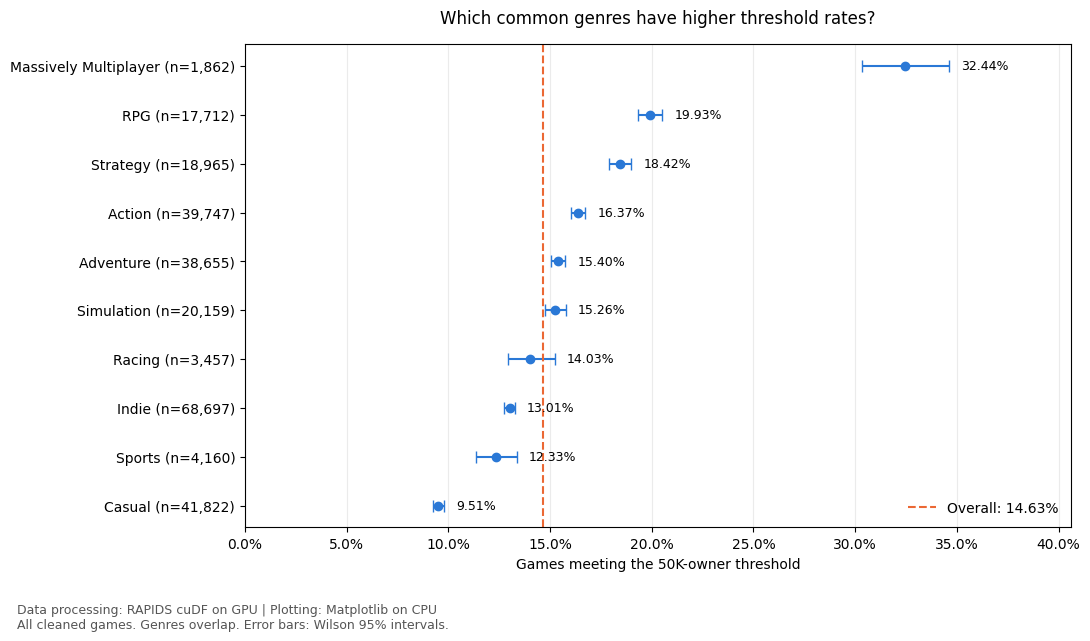

In [5]:
fig, ax = plt.subplots(figsize=(11, 6.5))
y = np.arange(len(t4))
rates = t4["rate_pct"].to_numpy()
errors = np.maximum(0, np.vstack([
    rates - t4["lower_pct"].to_numpy(), t4["upper_pct"].to_numpy() - rates
]))
ax.errorbar(rates, y, xerr=errors, fmt="o", color="#2a78d6", capsize=4)
ax.set_yticks(y, [f"{g} (n={int(n):,})" for g, n in zip(t4.index, t4.games)])
ax.invert_yaxis()
for i, rate in enumerate(rates):
    ax.text(t4["upper_pct"].iloc[i] + 0.6, i, f"{rate:.2f}%", va="center", fontsize=9)
ax.axvline(baseline, color="#eb6834", linestyle="--", label=f"Overall: {baseline:.2f}%")
ax.set_xlim(0, max(40, float(t4["upper_pct"].max()) + 6))
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlabel("Games meeting the 50K-owner threshold")
ax.set_title("Which common genres have higher threshold rates?", pad=15)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right", frameon=False)
fig.text(0.02, 0.025,
         "Data processing: RAPIDS cuDF on GPU | Plotting: Matplotlib on CPU\n"
         "All cleaned games. Genres overlap. Error bars: Wilson 95% intervals.",
         fontsize=9, color="#555555")
fig.tight_layout(rect=(0, 0.09, 1, 1))
fig.savefig(OUT / "04_genre_rates_gpu.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## 6. Save evidence and download
Downloads a ZIP containing the PNG, CSV and run-evidence JSON. Also choose **File → Download → Download .ipynb** to save your executed notebook with outputs for GitHub.

Replace the old **Q4 image** with `04_genre_rates_gpu.png`. Keep your original notebook intact: its Q6 depends on intermediate variables created in the original Q4 cell. Submit this GPU notebook alongside it.

The same cleaned CSV should reproduce approximately **32.44%** for Massively Multiplayer, **19.93%** for RPG and **18.42%** for Strategy. Check your new table before retaining the old insights.

Slide note: **Genre processing and success-rate calculations accelerated with RAPIDS cuDF on an NVIDIA GPU; visualization rendered with Matplotlib.**

This demonstrates GPU data processing. If your rubric specifically requires GPU rendering or GPU machine learning, that is a different requirement. No speedup has been measured.

In [6]:
digest = hashlib.sha256()
with DATA_PATH.open("rb") as handle:
    for chunk in iter(lambda: handle.read(1024*1024), b""):
        digest.update(chunk)
evidence = {
    "gpu_and_driver": gpu_info,
    "cudf_version": cudf.__version__, "cupy_version": cp.__version__,
    "input_file": DATA_PATH.name, "input_sha256": digest.hexdigest(),
    "games": len(gdf), "overall_rate_pct": baseline,
    "success_definition": "owners_low >= 50000",
    "gpu_processing": "cuDF read, split, explode, filter, deduplicate, groupby, rates, Wilson intervals",
    "cpu_processing": "Matplotlib rendering and pandas correctness check",
    "cpu_gpu_counts_and_rates_match": True,
    "speedup_measured": False
}
(OUT / "gpu_run_evidence.json").write_text(json.dumps(evidence, indent=2))
archive = shutil.make_archive("Steam_Q4_GPU_results", "zip", OUT)
files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>